In [2]:
# SETUP & DATASET

import os
import sys
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import importlib
import open3d as o3d
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

BASE_DIR = os.getcwd()
sys.path.append(os.path.join(BASE_DIR, 'models'))

class ChamferRegressionDataset(Dataset):
    def __init__(self, metadata, pcd_dir, indices, num_points=1024, is_training=False):
        self.metadata = metadata.iloc[indices].reset_index(drop=True)
        self.pcd_dir = pcd_dir
        self.num_points = num_points
        self.is_training = is_training
        self.cache = {}

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        if idx in self.cache:
            points, chamfer_out = self.cache[idx]
        else:
            filename = self.metadata.iloc[idx, 0]
            chamfer = self.metadata.iloc[idx, 3]

            file_path = os.path.join(self.pcd_dir, filename)
            pcd = o3d.io.read_point_cloud(file_path)

            if len(pcd.points) == 0:
                print(f"Warning: File {file_path} is empty or not found.")
                return

            # FPS sampling
            if len(pcd.points) > self.num_points:
                pcd = pcd.farthest_point_down_sample(self.num_points)

            xyz = np.asarray(pcd.points)
            normals = np.asarray(pcd.normals)
            has_normals = len(normals) > 0
            import re
            match = re.search(r'viewpoint_simulated(?:_noise)?_(\d+)', filename)
            view_index = int(match.group(1)) if match else 0
            
            dirname = os.path.dirname(filename)
            tf_path = os.path.join(self.pcd_dir.replace('processed_data', 'viewpoints_candidate/testing_data'), dirname, f"viewpoint_pose_{view_index}.npy")
            
            if os.path.exists(tf_path):
                T_object_camera = np.load(tf_path)
                T_camera_object = np.linalg.inv(T_object_camera)
                xyz_homogeneous = np.hstack((xyz, np.ones((xyz.shape[0], 1))))
                xyz = (T_camera_object @ xyz_homogeneous.T).T[:, :3]
                R_camera_object = T_camera_object[:3, :3]
                if has_normals:
                    normals = (R_camera_object @ normals.T).T
                else:
                    # Estimate normals in camera space
                    pcd_temp = o3d.geometry.PointCloud()
                    pcd_temp.points = o3d.utility.Vector3dVector(xyz)
                    pcd_temp.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5.0, max_nn=30))
                    pcd_temp.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
                    normals = np.asarray(pcd_temp.normals)
            else:
                print(f"Warning: TF not found at {tf_path}. Using untransformed data.")
                if not has_normals:
                    pcd_temp = o3d.geometry.PointCloud()
                    pcd_temp.points = o3d.utility.Vector3dVector(xyz)
                    pcd_temp.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5.0, max_nn=30))
                    pcd_temp.orient_normals_towards_camera_location(camera_location=np.array([0., 0., 0.]))
                    normals = np.asarray(pcd_temp.normals)
            # --- 2. Calculate Angle of Incidence (AoI) ---
            P = xyz
            V = -P
            V_norm = np.linalg.norm(V, axis=1, keepdims=True)
            V_normalized = V / (V_norm + 1e-6)
            
            N_norm = np.linalg.norm(normals, axis=1, keepdims=True)
            N_normalized = normals / (N_norm + 1e-6)
            
            aoi_cos = np.sum(V_normalized * N_normalized, axis=1, keepdims=True)
            
            # --- 3. Concatenate to [N, 7] ---
            points = np.hstack((xyz, normals, aoi_cos))

            # Spatial Normalization 
            points[:, 0:3] -= np.mean(points[:, 0:3], axis=0)
            scale = np.max(np.linalg.norm(points[:, 0:3], axis=1))
            if scale > 0:
                points[:, 0:3] /= scale

            # Padding if necessary
            if len(points) < self.num_points:
                idx_sample = np.random.choice(len(points), self.num_points, replace=True)
                points = points[idx_sample]

            chamfer_out = chamfer
            self.cache[idx] = (points, chamfer_out)

        points_np = points.copy()
        if self.is_training:
            import provider
            points_np = np.expand_dims(points_np, axis=0)
            points_np = provider.rotate_perturbation_point_cloud_with_normal(points_np, angle_sigma=0.06, angle_clip=0.08726)
            points_np = points_np.squeeze(0)

        points_tensor = torch.tensor(points_np, dtype=torch.float32).transpose(1, 0)
        target_tensor = torch.tensor([chamfer_out], dtype=torch.float32)

        return points_tensor, target_tensor


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [42]:
# INFERENCE CSV #

def generate_inference_csv(model_path, metadata_path, pcd_dir, device):
    print(f"Loading metadata from {metadata_path}...")
    metadata = pd.read_csv(metadata_path)
    
    # Create indices for ALL rows in the metadata
    all_indices = list(range(len(metadata)))
    
    # Initialize the dataset
    ds = ChamferRegressionDataset(
        metadata, pcd_dir, all_indices, num_points=5000,
        is_training=False, 
    )
    # Batch size of 16 and multiprocessing to speed up inference
    loader = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
    
    # Load model architecture and weights
    print(f"Loading model weights from {model_path}...")
    reg_module = importlib.import_module('pointnet2_regression')
    model = reg_module.get_model(normal_channel=True).to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    results = []
    
    print(f"Running inference on {len(all_indices)} samples...")
    with torch.no_grad():
        for i, (points, target) in enumerate(loader):
            points = points.to(device)
            pred, trans_feat = model(points)
            
            for b in range(points.size(0)):
                pred_val = pred[b].item()
                gt_val = target[b].item()
                error = abs(gt_val - pred_val)
                
                global_idx = all_indices[i * 16 + b]
                filename = metadata.iloc[global_idx]['filename']
                
                results.append({
                    'Original_Index': global_idx,
                    'Filename': filename,
                    'Split': 'Testing',
                    'GroundTruth_CD': gt_val,
                    'Predicted_CD': pred_val,
                    'Error': error
                })

    # Create DataFrame and Save
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by="Original_Index", ascending=True)
    
    save_path = "inference_results.csv"
    df_results.to_csv(save_path, index=False)
    print(f"Results saved to {save_path}")

# ==========================================
# EXECUTION
# ==========================================
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # EDIT THESE VARIABLES FOR NEW DATASETS
    MODEL_WEIGHTS = "best_regression_model.pth"
    
    # Example for running inference on an entirely new dataset:
    INFERENCE_EXPERIMENT = "test_7_simulation"
    INFERENCE_METADATA_PATH = f'../anr_pkg/src/processed_data/{INFERENCE_EXPERIMENT}/metadata.csv'
    INFERENCE_PCD_DIR = f'../anr_pkg/src/processed_data/{INFERENCE_EXPERIMENT}/'
    
    generate_inference_csv(
        model_path=MODEL_WEIGHTS,
        metadata_path=INFERENCE_METADATA_PATH,
        pcd_dir=INFERENCE_PCD_DIR,
        device=device
    )


Loading metadata from ../anr_pkg/src/processed_data/test_7_simulation/metadata.csv...
Loading model weights from best_regression_model.pth...
Running inference on 2592 samples...
Results saved to inference_results.csv


Loading results from inference_results_pointnet2_sampler.csv...

--- PERFORMANCE METRICS (216 samples) ---
Mean Absolute Error (MAE): 0.1503 mm
Root Mean Squared Error (RMSE): 0.1806 mm
R-Squared (R²): -4.2749
Max Error: 0.5630 mm
-------------------------------------------



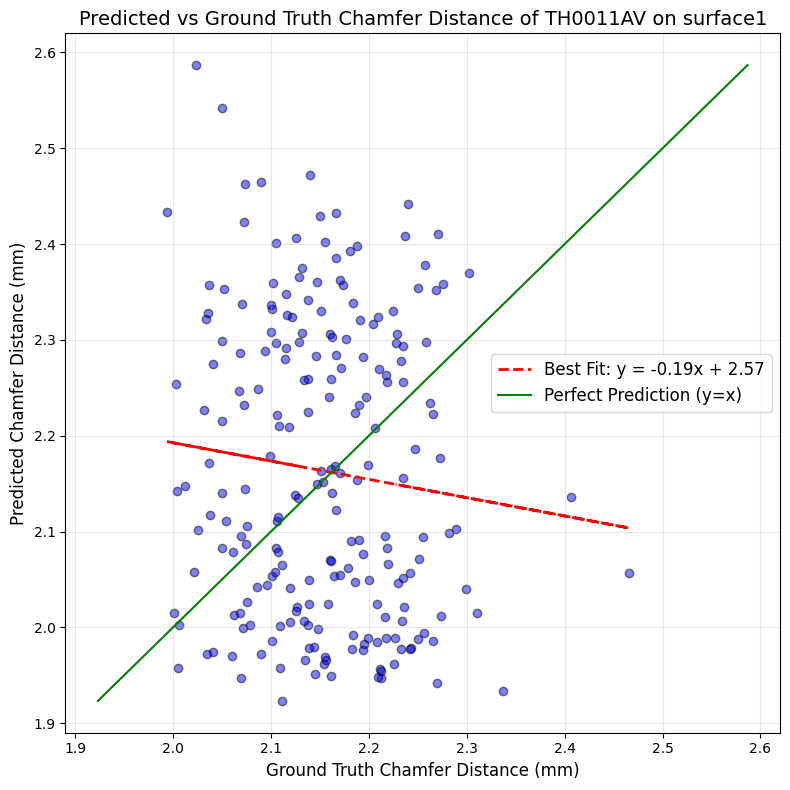

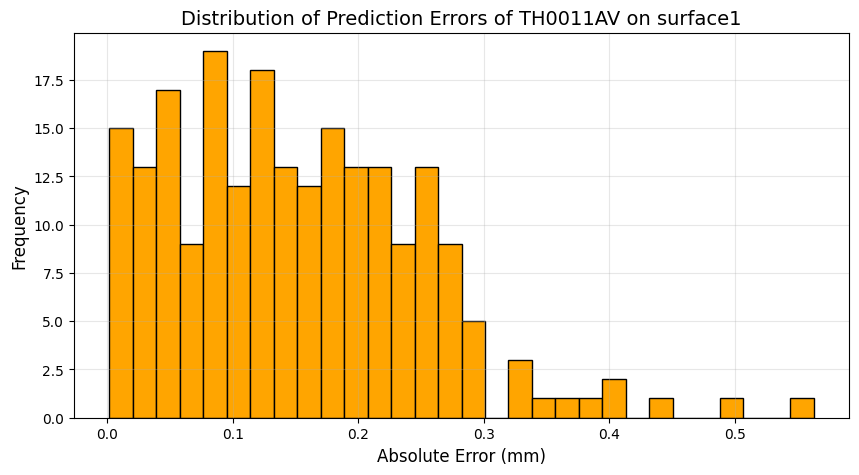

C:\Users\Alvan\AppData\Local\Temp\ipykernel_136360\4099938206.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby('Error_Bucket')['Raw_Error'].mean().reset_index()
C:\Users\Alvan\AppData\Local\Temp\ipykernel_136360\4099938206.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_counts = df.groupby('Error_Bucket')['Raw_Error'].count().reset_index()


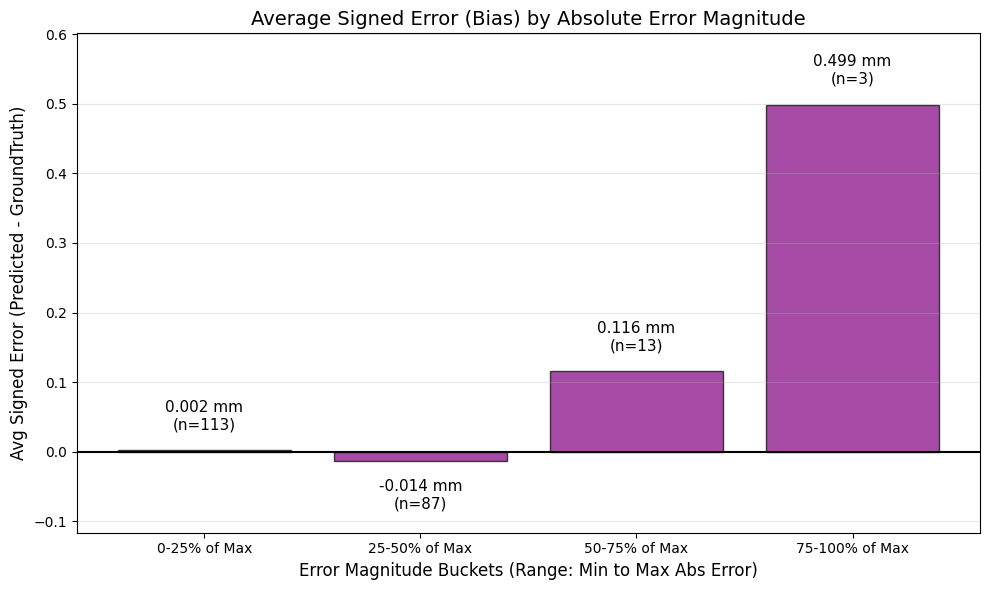

In [40]:
# ==========================================
# MODEL RESULT ANALYTICS
# ==========================================

TARGET_WORKPIECE = "TH0011AV"
TARGET_SURFACE = "surface1"

# 1. Load the inference results
results_path = "inference_results_pointnet2_sampler.csv"
print(f"Loading results from {results_path}...")
df = pd.read_csv(results_path)

# Optional: Filter for a specific workpiece if you only want to see unseen data
df = df[df['Filename'].str.contains(TARGET_WORKPIECE) & df['Filename'].str.contains(TARGET_SURFACE)]


y_true = df['GroundTruth_CD'].values
y_pred = df['Predicted_CD'].values
errors = df['Error'].values

# 2. Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
max_error = np.max(errors)

print(f"\n--- PERFORMANCE METRICS ({len(df)} samples) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} mm")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mm")
print(f"R-Squared (R²): {r2:.4f}")
print(f"Max Error: {max_error:.4f} mm")
print("-------------------------------------------\n")

# 3. Plot Prediction vs Ground Truth
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.5, color='blue', edgecolor='k')

# Calculate Line of Best Fit
m, b = np.polyfit(y_true, y_pred, 1)
plt.plot(y_true, m*y_true + b, color='red', linestyle='--', linewidth=2, label=f'Best Fit: y = {m:.2f}x + {b:.2f}')

# Perfect Prediction Line (y = x)
min_val = min(min(y_true), min(y_pred))
max_val = max(max(y_true), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='green', linestyle='-', linewidth=1.5, label='Perfect Prediction (y=x)')

plt.title(f'Predicted vs Ground Truth Chamfer Distance of {TARGET_WORKPIECE} on {TARGET_SURFACE}', fontsize=14)
plt.xlabel('Ground Truth Chamfer Distance (mm)', fontsize=12)
plt.ylabel('Predicted Chamfer Distance (mm)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Plot Error Distribution (Histogram)
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, color='orange', edgecolor='black')
plt.title(f'Distribution of Prediction Errors of {TARGET_WORKPIECE} on {TARGET_SURFACE}', fontsize=14)
plt.xlabel('Absolute Error (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# 5. Error Magnitude Bucketing and Bias Analysis
# Calculate raw signed error: Positive = Overpredicted, Negative = Underpredicted
df['Raw_Error'] = df['Predicted_CD'] - df['GroundTruth_CD']
df['Abs_Error'] = df['Error'] # Which is abs(gt - pred)

min_err = df['Abs_Error'].min()
max_err = df['Abs_Error'].max()

# Create 4 equal-width bins based on the max error range
bins = np.linspace(min_err, max_err, 5)
labels = ['0-25% of Max', '25-50% of Max', '50-75% of Max', '75-100% of Max']
df['Error_Bucket'] = pd.cut(df['Abs_Error'], bins=bins, labels=labels, include_lowest=True)

# Calculate the average raw (signed) error for each bucket
bucket_stats = df.groupby('Error_Bucket')['Raw_Error'].mean().reset_index()
bucket_counts = df.groupby('Error_Bucket')['Raw_Error'].count().reset_index()

# Plotting the average raw error per bucket
plt.figure(figsize=(10, 6))
bars = plt.bar(bucket_stats['Error_Bucket'].astype(str), bucket_stats['Raw_Error'], color='purple', edgecolor='black', alpha=0.7)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.title('Average Signed Error (Bias) by Absolute Error Magnitude', fontsize=14)
plt.xlabel('Error Magnitude Buckets (Range: Min to Max Abs Error)', fontsize=12)
plt.ylabel('Avg Signed Error (Predicted - GroundTruth)', fontsize=12)

# Calculate dynamic padding based on data range so labels don't fly off the plot
y_vals = bucket_stats['Raw_Error'].dropna()
y_max, y_min = y_vals.max(), y_vals.min()
y_range = y_max - (y_min if y_min < 0 else 0)
if y_range == 0: y_range = 0.1
padding = y_range * 0.05

# Add values on top of bars and sample count
for i, bar in enumerate(bars):
    yval = bar.get_height()
    count = bucket_counts['Raw_Error'].iloc[i]
    if not np.isnan(yval):
        offset = padding if yval >= 0 else -padding
        plt.text(bar.get_x() + bar.get_width()/2, yval + offset, 
                 f'{yval:.3f} mm\n(n={count})', ha='center', va='bottom' if yval >= 0 else 'top', fontsize=11)

# Ensure y-limits comfortably fit the text
plt.ylim(min(0, y_min - padding * 4), y_max + padding * 4)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Loading results from inference_results_pointnet2_sampler.csv...


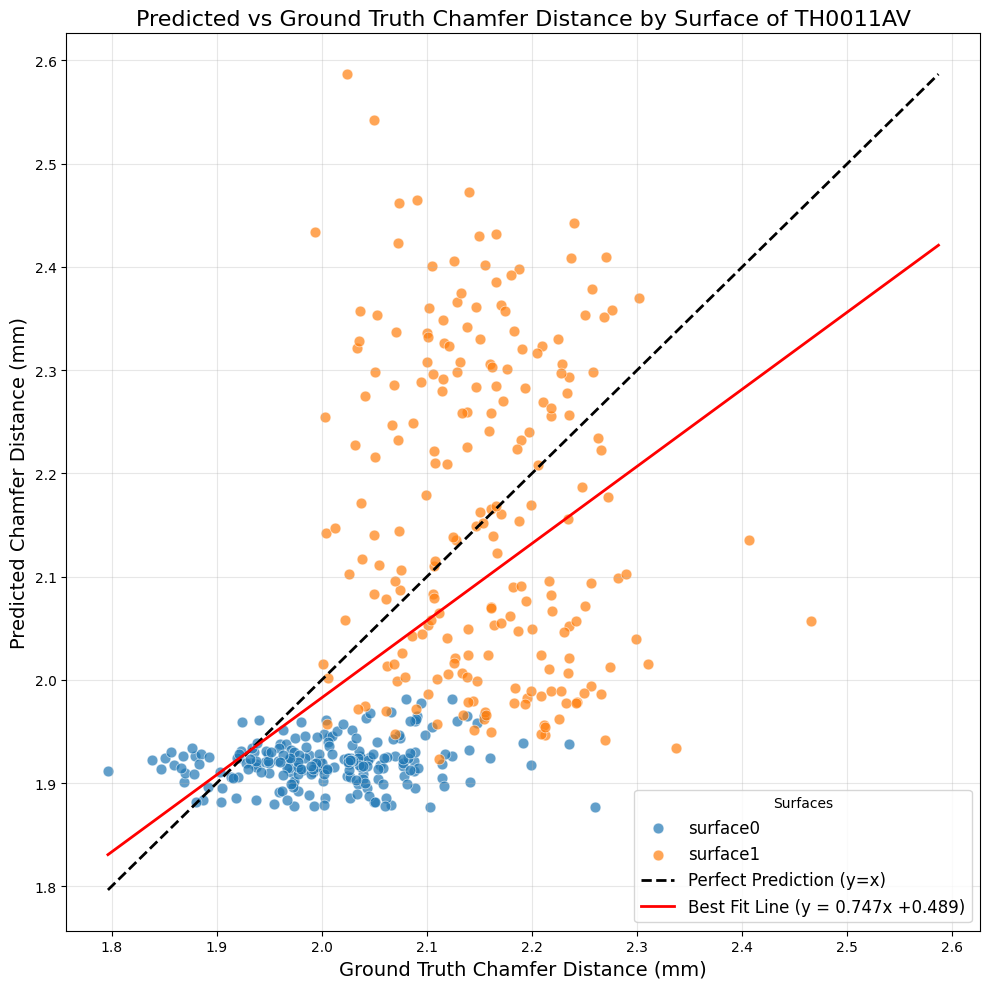

In [38]:
# ==========================================
# PARITY PLOT BY SURFACE
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

TARGET_WORKPIECE = 'TH0011AV'

results_path = "inference_results_pointnet2_sampler.csv"
print(f"Loading results from {results_path}...")
df = pd.read_csv(results_path)

df = df[df['Filename'].str.contains(TARGET_WORKPIECE)]


# Extract surface name from the filename
def extract_surface(filename):
    match = re.search(r'(surface\d+)', filename)
    if match:
        return match.group(1)
    return "unknown"

df['Surface'] = df['Filename'].apply(extract_surface)

plt.figure(figsize=(10, 10))

surfaces = sorted(df['Surface'].unique())

# Use the beautiful Tableau 10 palette (without interpolation!)
colors = plt.cm.tab10.colors

for i, surface in enumerate(surfaces):
    subset = df[df['Surface'] == surface]
    # alpha=0.7 with thin white edges gives a modern, clean look with good contrast
    plt.scatter(subset['GroundTruth_CD'], subset['Predicted_CD'], 
                alpha=0.7, color=colors[i % len(colors)], edgecolor='white', linewidth=0.5, label=surface, s=60)

y_true = df['GroundTruth_CD'].values
y_pred = df['Predicted_CD'].values
min_val = min(min(y_true), min(y_pred))
max_val = max(max(y_true), max(y_pred))

# Perfect Prediction Line (y = x)
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

# Overall Best Fit Line (Linear Regression)
m, b = np.polyfit(y_true, y_pred, 1)
plt.plot([min_val, max_val], [m*min_val + b, m*max_val + b], color='red', linestyle='-', linewidth=2, label=f'Best Fit Line (y = {m:.3f}x {b:+.3f})')

plt.title(f'Predicted vs Ground Truth Chamfer Distance by Surface of {TARGET_WORKPIECE}', fontsize=16)
plt.xlabel('Ground Truth Chamfer Distance (mm)', fontsize=14)
plt.ylabel('Predicted Chamfer Distance (mm)', fontsize=14)
plt.legend(fontsize=12, loc='best', title='Surfaces')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
